Given a folder containing 5–10 sample KYC images, use a for loop to run OCR on each file and store the results in a list.

In [2]:
pip install opencv-python pytesseract

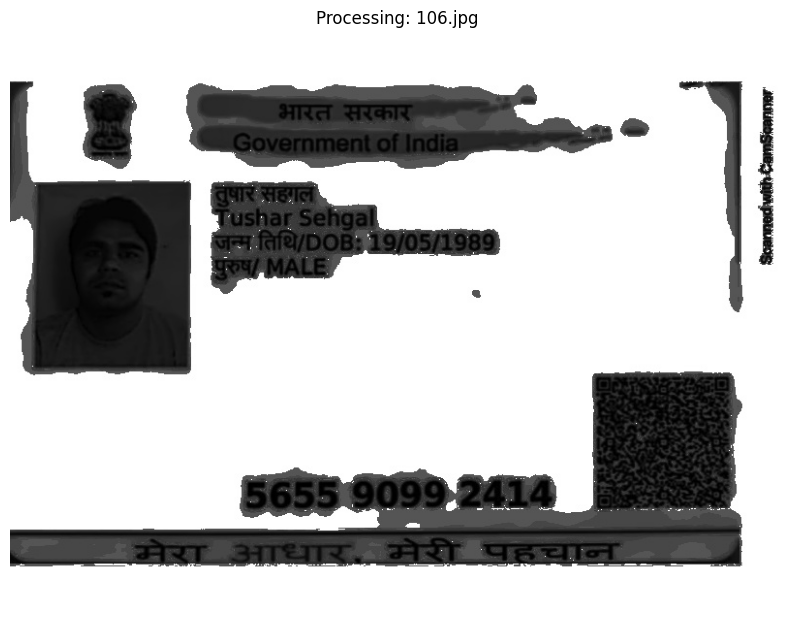

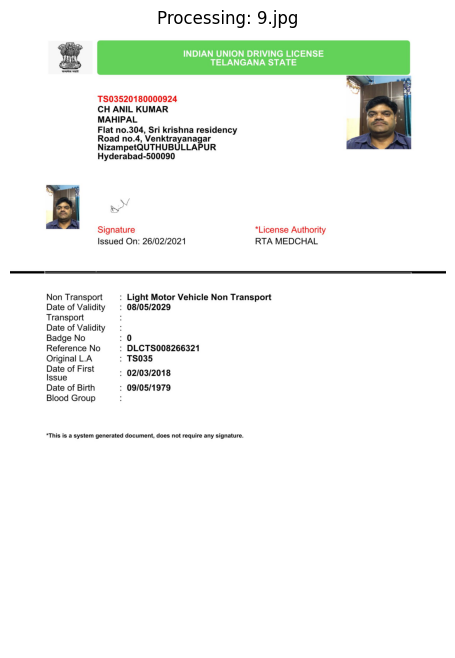

File: 106.jpg
Text: 
----------------------------------------
File: 9.jpg
Text: TS03520180000924
CH ANIL KUMAR
MAHIPAL

Flat no.304, Sri krishna residency
Road no.4, Venktrayanagar
NizampetQUTHUBULLAPUR

 
     
    

INDIAN UNION DRIVING LICENSE
TELANGANA STATE

Hyderabad-500090

we

Signature *License Authority
Issued On: 26/02/2021 RTA MEDCHAL

 

Non Transport
Date of Validity
Transport

Date of Validity
Badge No
Reference No
Original L.A
Date of First
Issue

Date of Birth
Blood Group

: Light Motor Vehicle Non Transport
: 08/05/2029

:0
: DLCTS008266321
: TS035

: 02/03/2018
: 09/05/1979

*This is a system generated document, does not require any signature.
----------------------------------------


In [4]:
import os
import cv2
import pytesseract
import matplotlib.pyplot as plt

# List of image paths provided by the user
image_paths = [
    '/content/106.jpg',
    '/content/9.jpg'
]

ocr_results = [] # list to store extracted text

for file_path in image_paths:
    # Extract file name for storage
    file_name = os.path.basename(file_path)

    # Process only if the file exists and is an image (based on extension)
    if os.path.exists(file_path) and file_name.lower().endswith((".png", ".jpg", ".jpeg")):
        image = cv2.imread(file_path)

        # Check if image was loaded successfully
        if image is None:
            print(f"Warning: Could not load image {file_name}. Skipping.")
            continue

        # Display the image
        plt.figure(figsize=(10, 8))
        plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB)) # Convert BGR to RGB for correct display
        plt.title(f"Processing: {file_name}")
        plt.axis('off') # Hide axes for cleaner image display
        plt.show()

        # Convert to grayscale (improves OCR)
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

        # Run OCR
        text = pytesseract.image_to_string(gray)

        # Store result
        ocr_results.append({
            "file_name": file_name,
            "extracted_text": text.strip()
        })
    else:
        print(f"Warning: File {file_name} is not a valid image or does not exist. Skipping.")

# Print results
for result in ocr_results:
    print("File:", result["file_name"])
    print("Text:", result["extracted_text"])
    print("-" * 40)